#### Ex.3 Flipping qubits in the Lab
The following exercise is done in Julia using Matplotlib as plotting backend. I start by loading all necessary packages

In [5]:
using CSV, LaTeXStrings, PythonCall, KernelDensity, StatsBase

include(string(@__DIR__, "/Source.jl"))
@py import matplotlib as mpl
@py import matplotlib.pyplot as plt

mpl.use("pgf");

Next I load the data and place it in a DataFrame (similar to a pandas DataFrame in Python). I also place the data in a matrix and an array for later use. Looking at the data we can filter out values above 100 as these will skew the analysis

In [16]:
# create header for data
columns = ["start", "stop", "pulse_length", "doppler", "PMT_sum"]
[push!(columns, "PMT$i") for i in 1:100]
# import data
df = CSV.read(joinpath(@__DIR__, "PMT1_2_excel_NO_mean_exc.txt"), DataFrame, header=columns, delim="	", skipto=2)

x = 1:length(df[!, "PMT1"])

# collect all PMTs in one array
PMT_all = []
for i in 1:100
    push!(PMT_all, df[!, "PMT$i"])
end

PMT_mat = hcat(PMT_all...)
PMT_arr = vcat(PMT_all...)
println("μ = ", mean(PMT_arr), " σ = ", std(PMT_arr))
# remove values > 100 
PMT_arr = PMT_arr[PMT_arr .< 100];

μ = 24.650851063829787 σ = 28.187868593898443


To distinguish between $|0\rangle$ and $|1\rangle$ states I bin the data using a width of 1 (since PMT occurrences come in integer values) and then fit a linear combination of two gaussian distributions to the binned data. From the fits I take the mean value and associate all values within $2\sigma$ to be registered as valid event. 

2sigma interval for gauss1: 8.28(4)+-5.714818540194848
2sigma interval for gauss2: 39.78(12)+-13.17648723240933


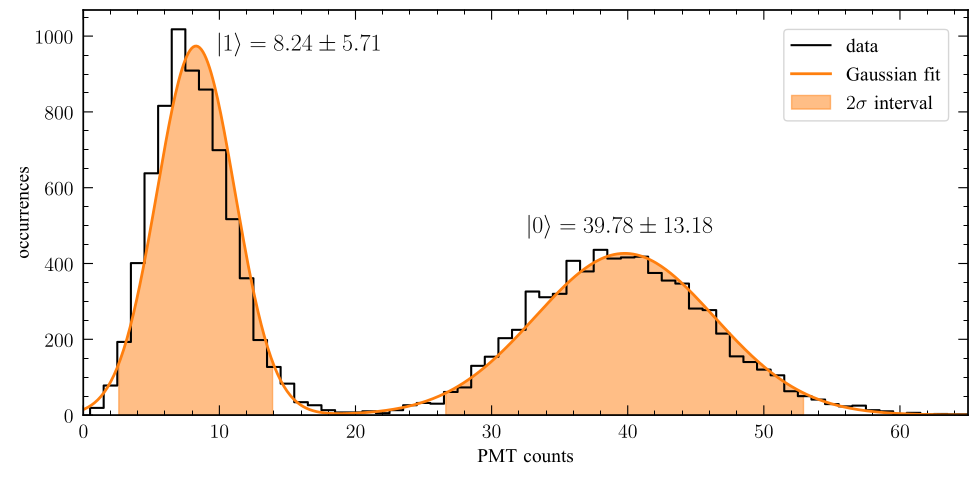

In [17]:
gauss(x, p) = @. p[1] * exp(-((x - p[2])^2) / (2 * p[3]^2)) + p[4] * exp(-(x - p[5])^2 / (2 * p[6]^2))

# bin data
h = fit(Histogram, PMT_arr, 0:1:100)
centers = h.edges[1][1:end-1] .+ diff(h.edges[1]) / 2

popt, ci = bootstrap(gauss, centers, h.weights, p0=[1000., 10.0, 1.0, 300., 30., 5.], unc=true, redraw=false)

# plot as nice 2D histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(centers, h.weights, color="black", label=L"\mathrm{data}", ds="steps")

# plot fit
ax.plot(ci.x, gauss(ci.x, nom.(popt)), color="C1", label=L"\mathrm{Gaussian\ fit}", lw=2)

# mark 2sigma intervals for both gaussians
σ = 2
ax.fill_between(ci.x, 0, gauss(ci.x, nom.(popt)), where=(ci.x .> (nom(popt[2]) - σ*nom(popt[3]))) .& (ci.x .< (nom(popt[2]) + σ*nom(popt[3]))), color="C1", alpha=0.5, label=L"$2\sigma\ \mathrm{interval}$")
ax.fill_between(ci.x, 0, gauss(ci.x, nom.(popt)), where=(ci.x .> (nom(popt[5]) - σ*nom(popt[6]))) .& (ci.x .< (nom(popt[5]) + σ*nom(popt[6]))), color="C1", alpha=0.5)

# add interval as text
println("2sigma interval for gauss1: ", popt[2], "+-", σ*nom(popt[3]))
println("2sigma interval for gauss2: ", popt[5], "+-", σ*nom(popt[6]))
ax.text(0.15, 0.9, L"|1\rangle = 8.24\pm 5.71", fontsize=18, transform=ax.transAxes)
ax.text(0.5, 0.45, L"|0\rangle = 39.78\pm 13.18", fontsize=18, transform=ax.transAxes)

# plot KernelDensity
# y = kde(PMT_arr, bandwidth=1)
# ax.plot(y.x, y.density, color="red", label="KernelDensity")

plt.legend()
plt.xlabel(L"$\mathrm{PMT\ counts}$")
plt.ylabel(L"$\mathrm{occurrences}$")
plt.xlim(0, 65)
plt.ylim(bottom=0)

plt.tight_layout()
plt.gcf()

Next we replace all entries in the PMT value matrix with either 0 or 1 if they fall into the interval and set them to -1 if they do not. After normalizing the data I plot it and fit a function of the form $f(t) = \sin^2(\Omega t + \varphi)$ to the both traces. The uncertainty in the cout rates can be estimated using $\delta = \sqrt{p(1-p)/n}$ with $n$ being the amount of datapoints used for estimating the probability (eg. the amount of succesfully identified $|0\rangle$ and $|1\rangle$ states).

fit params for |0>: Measurement{Float64}[0.1842(4), -0.026(15)]
fit params for |1>: Measurement{Float64}[0.1843(4), 1.543(15)]


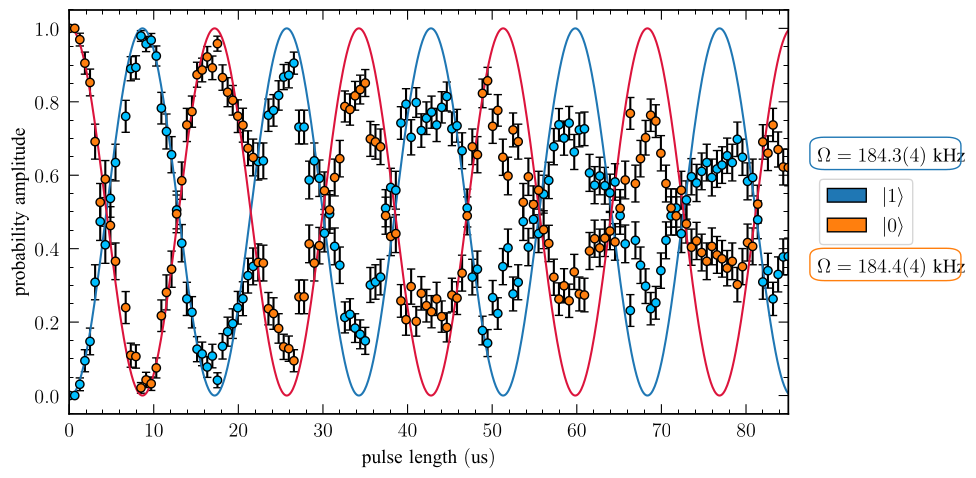

In [22]:
# create mask by associating 2sigma of gauss1 with 0 and 2sigma interval of gauss2 with 1
# replace values in PMT_mat with 0 and 1
A = findall(x -> x > (nom(popt[2]) - σ*nom(popt[3])) && x < (nom(popt[2]) + σ*nom(popt[3])), PMT_mat)
B = findall(x -> x > (nom(popt[5]) - σ*nom(popt[6])) && x < (nom(popt[5]) + σ*nom(popt[6])), PMT_mat)
PMT_mat[A] .= 0
PMT_mat[B] .= 1
# replace all values > 1 with -1
PMT_mat[PMT_mat .> 1] .= -1

# count 0s and 1s for each column 
Pp0 = [count(x -> x == 0, PMT_mat[i, :]) for i in 1:size(PMT_mat, 1)]
Pp1 = [count(x -> x == 1, PMT_mat[i, :]) for i in 1:size(PMT_mat, 1)]
# convert arrays to float
norm = Pp0 + Pp1
P0 = Pp0 ./ norm
P1 = Pp1 ./ norm

perr(x, n) = @. sqrt(x * (1 - x) / n)
# calculate error
P0err = perr(P0, norm)
P1err = perr(P1, norm)

# fit sin^2 function to data
model(x, p) = @. sin(p[1] * x + p[2])^2

popt0, ci0 = bootstrap(model, df[!, "pulse_length"], P0, yerr=P0err, p0=[0.03*2*pi, 0.], unc=true, redraw=false)
popt1, ci1 = bootstrap(model, df[!, "pulse_length"], P1, yerr=P1err, p0=[0.03*2*pi, 0.], unc=true, redraw=false)
println("fit params for |0>: ", popt0)
println("fit params for |1>: ", popt1)

# plot sum over matrix vs pulse length
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(df[!, "pulse_length"], P0, yerr=P0err, fmt="o", mfc="deepskyblue", mec="k", ecolor="k", capsize=3)
ax.errorbar(df[!, "pulse_length"], P1, yerr=P1err, fmt="o", mfc="C1", mec="k", ecolor="k", capsize=3)
xlims, ylims = ax.get_xlim(), ax.get_ylim()

# plot fit
ax.plot(ci0.x, model(ci0.x, nom.(popt0)), c="C0")
ax.plot(ci1.x, model(ci1.x, nom.(popt1)), c="crimson")

# add fit params as text
ax.text(1.04, 0.625, L"\Omega = 184.3(4)\ \mathrm{kHz}", fontsize=14, transform=ax.transAxes)
rect = mpl.patches.FancyBboxPatch((1.05, 0.625), 0.17, 0.04, ec="C0", fc="none", transform=ax.transAxes, boxstyle=mpl.patches.BoxStyle("Round", pad=0.02))
fig.add_artist(rect)

ax.text(1.04, 0.35, L"\Omega = 184.4(4)\ \mathrm{kHz}", fontsize=14, transform=ax.transAxes)
rect = mpl.patches.FancyBboxPatch((1.05, 0.35), 0.17, 0.04, ec="C1", fc="none", transform=ax.transAxes, boxstyle=mpl.patches.BoxStyle("Round", pad=0.02))
fig.add_artist(rect)

# create dummy label for legend
ax.fill_between(-1, [0], [1], color="C0", ec="k", alpha=1, label=L"|1\rangle")
ax.fill_between(-1, [0], [1], color="C1", ec="k", alpha=1, label=L"|0\rangle")

plt.xlim(left=0, right=df[!, "pulse_length"][end])
plt.xlabel(L"$\mathrm{pulse\ length\ (us)}$")
plt.ylabel(L"$\mathrm{probability\ amplitude}$")
plt.legend(loc="right", bbox_to_anchor=(1.2, 0.5))

plt.tight_layout()
plt.gcf()

This model captures the oscillatory behaviour leading to a frequency of $\Omega = 184.3(4)\ \mathrm{kHz}$. The amplitude however decreases which is not captured be the model. To fix this I include an exponential decay in the amplitude which can be expressed in the following way: $f(t) = \frac{1}{2}(1 - A\exp(-t/\tau) \cos(2\Omega t + \varphi))$. Here the $\sin^2$ term is replaced by using the identity $\cos(2x) = 1 - 2\sin^2(x)$. 

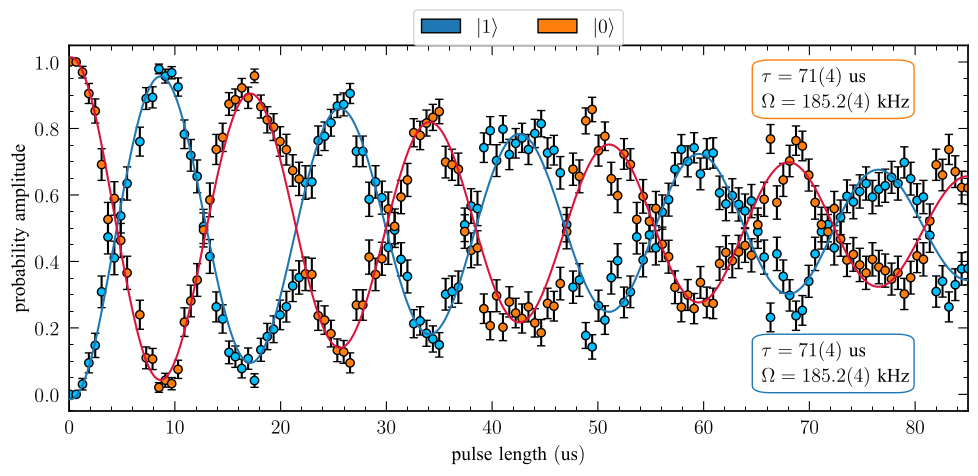

In [26]:
# new model with exponential decay that goes to 0.5 for t->infty
model2(x, p) = @. 0.5 * (1 - p[1] * exp(-x/p[4]) * cos(p[2]*2 * x + p[3]))
popt0, ci0 = bootstrap(model2, df[!, "pulse_length"], yerr=P0err, P0, p0=[1., 0.03*2*pi, 0., 70.], unc=true, redraw=false, p=0.99)
popt1, ci1 = bootstrap(model2, df[!, "pulse_length"], yerr=P1err, P1, p0=[1., 0.03*2*pi, 3., 70.], unc=true, redraw=false, p=0.99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(df[!, "pulse_length"], P0, yerr=P0err, fmt="o", mfc="deepskyblue", mec="k", ecolor="k", capsize=3)
ax.errorbar(df[!, "pulse_length"], P1, yerr=P1err, fmt="o", mfc="C1", mec="k", ecolor="k", capsize=3)
xlims, ylims = ax.get_xlim(), ax.get_ylim()
# plot fit
ax.plot(ci0.x, model2(ci0.x, nom.(popt0)), c="C0", zorder=5)
ax.plot(ci1.x, model2(ci1.x, nom.(popt1)), c="crimson", zorder=5)

# add fit params as text
ax.text(0.77, 0.9, L"\tau = 71(4)\ \mathrm{us}", fontsize=14, transform=ax.transAxes)
ax.text(0.77, 0.83, L"\Omega = 185.2(4)\ \mathrm{kHz}", fontsize=14, transform=ax.transAxes)
rect = mpl.patches.FancyBboxPatch((0.78, 0.82), 0.14, 0.12, ec="C1", fc="none", transform=ax.transAxes, boxstyle=mpl.patches.BoxStyle("Round", pad=0.02))
ax.add_patch(rect)

ax.text(0.77, 0.15, L"\tau = 71(4)\ \mathrm{us}", fontsize=14, transform=ax.transAxes)
ax.text(0.77, 0.08, L"\Omega = 185.2(4)\ \mathrm{kHz}", fontsize=14, transform=ax.transAxes)
rect = mpl.patches.FancyBboxPatch((0.78, 0.07), 0.14, 0.12, ec="C0", fc="none", transform=ax.transAxes, boxstyle=mpl.patches.BoxStyle("Round", pad=0.02))
ax.add_patch(rect)

# create dummy label for legend
ax.fill_between(-1, [0], [1], color="C0", ec="k", alpha=1, label=L"|1\rangle")
ax.fill_between(-1, [0], [1], color="C1", ec="k", alpha=1, label=L"|0\rangle")

ax.set_ylim(ylims)
plt.xlim(left=0, right=df[!, "pulse_length"][end])
plt.xlabel(L"$\mathrm{pulse\ length\ (us)}$")
plt.ylabel(L"$\mathrm{probability\ amplitude}$")
plt.legend(ncols=2, loc="upper center", bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
plt.gcf()

This model accurately captures the observed behaviour with a frequency of $\Omega = 185.2(4)\ \mathrm{kHz}$ and a $1/e$ time of $\tau = 71(4)\ µ\mathrm{s}$